In [49]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_bvp
import time


## Oppgave 1

#### Oppgave 1c

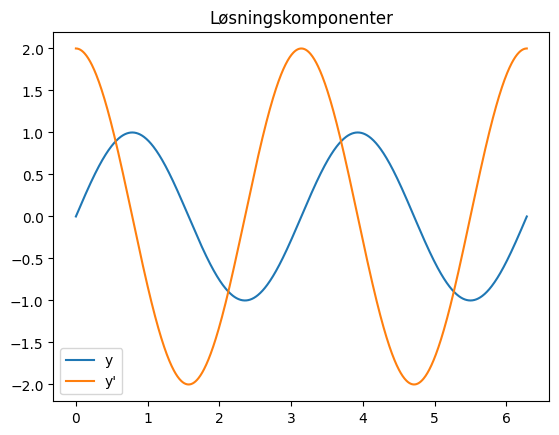

{'Accepted steps': 1070, 'Discarded steps': 1}


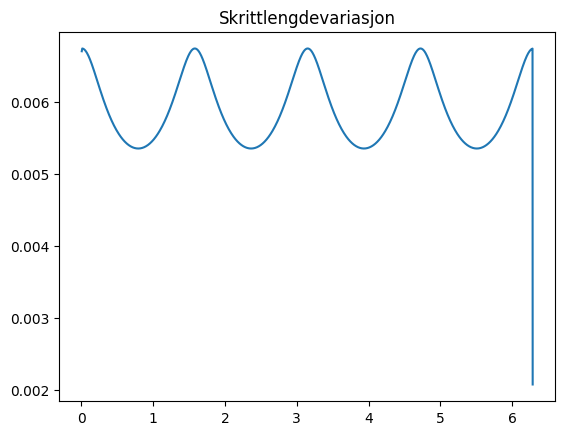

In [50]:
def f(x,y):
    return np.array([y[1], -4 * np.sin(2 * x)])

def rk(x0, xend, y0, f, h0, tol, alpha):
    x = x0
    h = h0
    y = y0.copy()
    n = 0 #accepted
    nd = 0 #discarded
    k1 = f(x,y)
    X = [x]
    Y = [y]

    while xend > x:
        h = min(h, xend - x)
        xn = X[n]
        yn = Y[n]
        xnext = xn + h
        k2 = f(xn + 0.5 * h, yn + 0.5 * h * k1)
        k3 = f(xn + 0.75 * h, yn + 0.75 * h * k2)
        ynext = yn + 1/9 * h * (2 * k1 +3 * k2 +4 * k3)
        k4 = f(xn + h, ynext)
        znext = yn + 1/24 * h * (7 * k1 + 6 * k2 + 8 * k3 + 3 * k4)
        est = np.linalg.norm(ynext - znext)
        if est < tol:
            n += 1
            k1 = k4
            x = x + h
            y = znext
            X.append(x)
            Y.append(y.copy())
        else:
            nd += 1
        
        if est == 0:
            h = 2*h
        else:
            h = alpha*h*(tol/est)**(1/3)

    Xa = np.array(X)
    Ya = np.array(Y)
    stats = {"Accepted steps": n, "Discarded steps": nd}
    return Xa, Ya, stats

x0 = 0.0
y0 = np.array([0.0, 2.0])
xend = 2 * np.pi
alpha = 0.8
tol = 1e-7
h0 = 0.1
X, Y, stats = rk(x0, xend, y0, f, h0, tol,alpha)

plt.plot(X, Y[:, 0], label = "y")
plt.plot(X, Y[:, 1], label = "y'")
plt.title("Løsningskomponenter")
plt.legend()
plt.show()
print(stats)
plt.plot(X[1:], np.diff(X))
plt.title("Skrittlengdevariasjon")
plt.show()





$est_{n+1} = ||\vec{y}_{n+1} - \vec{z}_{n+1}||$ 

$h_{new} = \alpha * h_n * (tol / est)^{1/3}$ 

Figuren for løsningskomponentene viser hvordan funksjonene til y og y' ser ut. Stats viser at det er 1070 aksepterte steg, og 1 uakseptert steg. 
Plottet for skrittlengdevariasjon viser at skrittene varierer periodisk slik som y og y'. Fra formelen for $est_{n+1}$ og $h_{new}$ ser vi at skrittlengden øker når estimatet blir mindre, og minker når estimatet øker. Dette skjer med en periode på $2\pi$ som kommer fra differensialligningen. 

sammenlign/lag tabell med ulike alpha og tol for å se hvor mange steg man får

#### Oppgave 1d

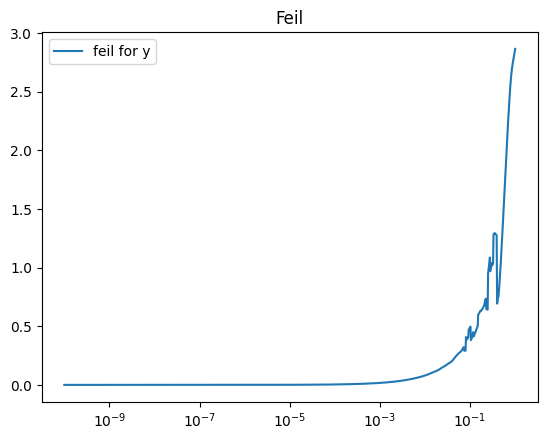

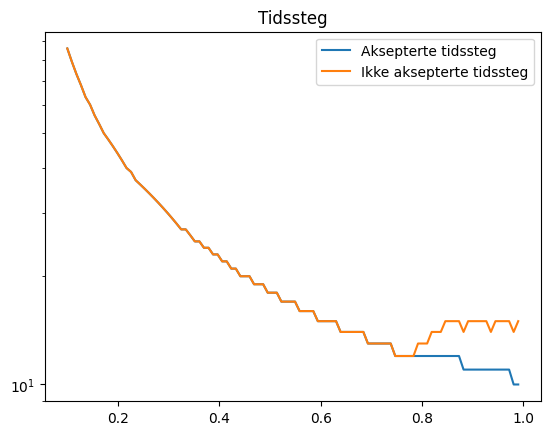

In [51]:
alphas = np.linspace(0.1, 0.99, 100)
tols = np.logspace(-10, 0, 1000)

a = []
b = []
accepted = []
total = []

alpha_fixed = 0.8


for tol in tols:
    X, Y, stats_new = rk(x0, xend, y0, f, h0, tol, alpha_fixed)
    a.append(np.max(np.abs(Y[:, 0] - np.sin(2*X))))
    b.append(np.max(np.abs(Y[:, 1] - 2*np.cos(2*X))))

tol_fixed = 0.1
for alpha in alphas:
    X, Y, stats_new = rk(x0, xend, y0, f, h0, tol_fixed, alpha)
    accepted.append(stats_new["Accepted steps"])
    total.append(stats_new["Discarded steps"]+stats_new["Accepted steps"])

plt.plot(tols, a, label="feil for y")
#plt.plot(tols, b, label="feil for y'")
plt.legend()
plt.title("Feil")
plt.xscale("log")
plt.show()

plt.plot(alphas, accepted, label="Aksepterte tidssteg")
plt.plot(alphas, total, label="Ikke aksepterte tidssteg")
plt.legend()
plt.title("Tidssteg")
plt.yscale("log")
plt.show()

Fra den første figuren ser vi at feilen øker med X for begge løsningskomponentene, men feilen er fortsatt veldig liten. Økningen kan skyldes at flere steg/iterasjoner fører til større feil sammenlignet med det analytiske svaret, men at de forsatt er riktige i forhold til hverandre, da variasjonen i feil ligner plottet fra 1c.

Plottet av tiddsteg som variasjon av $\alpha$ viser at de aksepterte stegene blir mindre når $\alpha$ øker, mens de avslåtte tiddstegene alltid er lik 1.

#### Oppgave 1e

In [52]:
def secant(g, z0, z1, tol):
    z_nm2 = z0
    z_nm1 = z1
    while True:
        zn = (z_nm2 * g(z_nm1) - z_nm1 * g(z_nm2)) / (g(z_nm1) - g(z_nm2))
        est = abs(z_nm1 - zn)
        if est < tol:
            break
        z_nm2 = z_nm1
        z_nm1 = zn
    return zn

z0 = 0
z1 = 0.1
tol = 1e-7

def g(z):
    return z + np.sin(z) + np.cos(z)
#Sekant
print(secant(g, z0, z1, tol)) 
#Analytisk
z = sp.symbols('z')
print(sp.nsolve(z + sp.sin(z) + sp.cos(z), 0)) 


-0.4566247045676011
-0.456624704567631


Den numeriske løseren viser at sekantmetoden er implementert riktig

#### Oppgave 1f

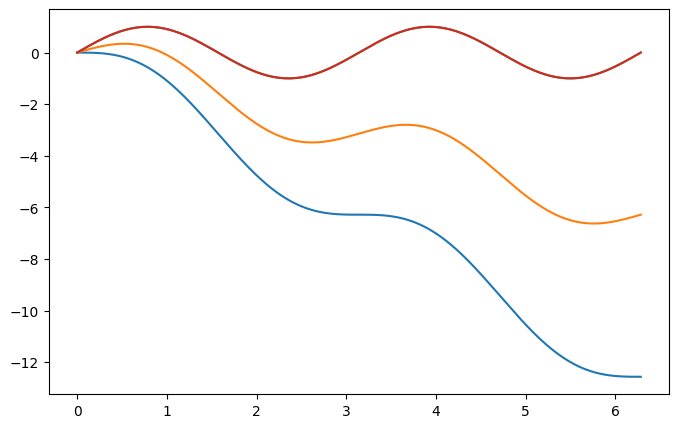

In [53]:
def secant_new(g, z0, z1, tol, max_iter=1000):
    roots = [z0, z1]
    z_nm2 = z0
    z_nm1 = z1

    for i in range(max_iter):
        zn = (z_nm2 * g(z_nm1) - z_nm1 * g(z_nm2)) / (g(z_nm1) - g(z_nm2))
        roots.append(zn)

        if abs(z_nm1 - zn) < tol:
            return roots

        z_nm2 = z_nm1
        z_nm1 = zn

    raise ValueError("Konvergerer ikke")

def bvp(b, x0, xend, f, h0, tol, alpha):
    y_init = np.array([0.0, b], dtype=float)
    X, Y, stats = rk(x0, xend, y_init, f, h0, tol, alpha)
    return Y[-1, 0]

x0 = 0.0
y0 = np.array([0.0, 1],dtype=float )
xend = 2 * np.pi
alpha = 0.8
tol = 1e-7
h0 = 0.1

g = lambda b: bvp(b, x0, xend, f, h0, tol, alpha)

b0 = 0.0
b1 = 1.0

roots = secant_new(g, b0, b1, tol, max_iter=1000)

plt.figure(figsize=(8,5))
for i, b in enumerate(roots):
    y_init = np.array([0.0, b], dtype=float)
    X, Y, stats = rk(x0, xend, y_init, f, h0, tol, alpha)
    plt.plot(X, Y[:, 0], label=f"Iterasjon {i}: b={b:.6f}")



plt.show()
    

forklaring av plott

#### Oppgave 1g

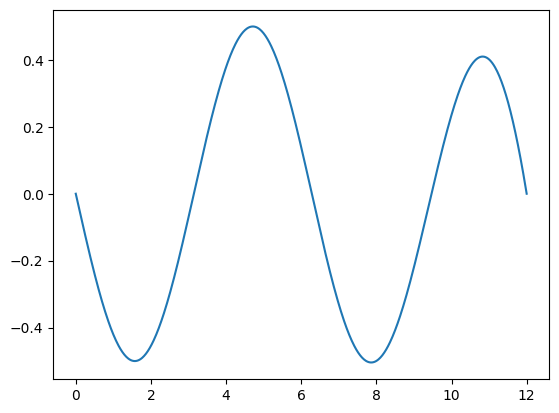

In [57]:
def f(x, y):
    return np.array([y[1], y[0] + np.sin(x)])

x0 = 0
xend = 12
y0 = np.array([0.0, b], dtype=float)
alpha = 0.8
tol = 1e-7
h0 = 0.1

b0 = 0.0
b1 = 1.0

start_num = time.perf_counter()

g = lambda b: bvp(b, x0, xend, f, h0, tol, alpha)

roots = secant_new(g, b0, b1, tol, max_iter=1000)
y0[1] = roots[-1]
X, Y, stats = rk(x0, xend, y0, f, h0, tol, alpha)
plt.plot(X, Y[:, 0], label=f"Løsning med b = {roots[-1]:.6f}")

end_num = time.perf_counter()

plt.show()



Forklaring kode

#### Oppgave 1h

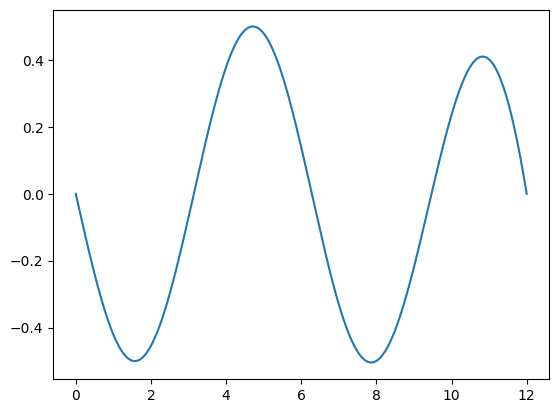

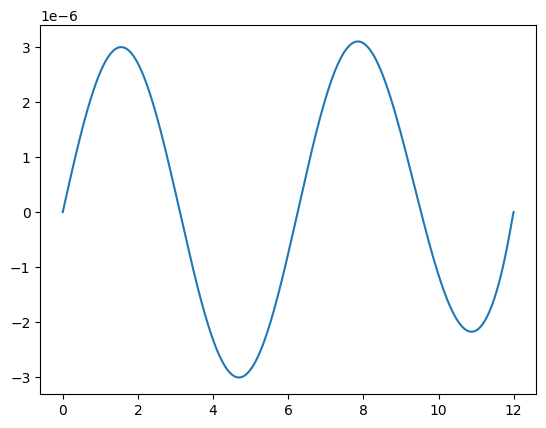

Tid 1: 0.7276 seconds
Tid 2: 0.0457 seconds


In [58]:
def fun(x,y):
    return np.vstack([y[1], y[0] + np.sin(x)])

def bc(ya, yb):
    return np.array([ya[0], yb[0]]) 


start_scipy = time.perf_counter()

x = np.copy(X)
y = np.zeros((2, x.size))

res = solve_bvp(fun, bc, x, y)

plt.plot(res.x, res.y[0])
plt.show()
end_scipy = time.perf_counter()


plt.plot(x, Y[:, 0] - res.sol(x)[0] )
plt.show()

print(f"Tid 1: {end_num - start_num:.4f} seconds")
print(f"Tid 2: {end_scipy - start_scipy:.4f} seconds")

Scipy sin løser er mye raskere, så den er til å foretrekke.